In [100]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [101]:
import pandas as pd
import json
import sys
from pathlib import Path
from utils import *
import joblib
from utils.helper_classification import *
# add the directory to the path
sys.path.insert(0, str(Path.cwd()))

### A note regarding DLIF results

Since deep learning models are difficult to reproduce due to system configuration differences, we have provided the predictions files for the models used in the paper. Below you can set the toggle to use our results or use the results from the trained models in `dlif_pipeline/results`.

In [9]:
use_preds = True

# First, run metric evaluations if using our set prediction files
if use_preds:
    generate_dlif_metric_files()


📊 Processing outcome: DCR
  ✅ rwd: AUC=0.7008 [0.6383, 0.7633], F1=0.6887, Sens=0.6154, Spec=0.7212
  ✅ rwd_dp: AUC=0.6493 [0.5831, 0.7155], F1=0.6688, Sens=0.6272, Spec=0.5962
  ✅ rwd_radfm: AUC=0.6626 [0.5983, 0.7268], F1=0.6769, Sens=0.6509, Spec=0.5577
  ✅ rwd_radfm_dp: AUC=0.6596 [0.5935, 0.7257], F1=0.7066, Sens=0.6982, Spec=0.5481
  ✅ rwd_radfm_dp_genomics: AUC=0.6459 [0.5801, 0.7117], F1=0.7102, Sens=0.7396, Spec=0.4423
  ✅ rwd_radpy: AUC=0.6637 [0.5991, 0.7283], F1=0.6537, Sens=0.5976, Spec=0.6250
  ✅ rwd_radpy_dp: AUC=0.6219 [0.5554, 0.6885], F1=0.5764, Sens=0.4911, Spec=0.6538
  ✅ rwd_radpy_dp_genomics: AUC=0.6445 [0.5782, 0.7108], F1=0.6028, Sens=0.5030, Spec=0.7308

📊 Processing outcome: ORR
  ✅ rwd: AUC=0.6853 [0.6193, 0.7513], F1=0.5481, Sens=0.6000, Spec=0.6854
  ✅ rwd_dp: AUC=0.6558 [0.5874, 0.7241], F1=0.5243, Sens=0.5684, Spec=0.6798
  ✅ rwd_radfm: AUC=0.6573 [0.5897, 0.7249], F1=0.5683, Sens=0.8316, Spec=0.4157
  ✅ rwd_radfm_dp: AUC=0.6727 [0.6071, 0.7383], F1=0.55

## PLOT AUC RESULTS

run this section to reproduce **figure 2** and **figure 3** MLEF and DLIF results 

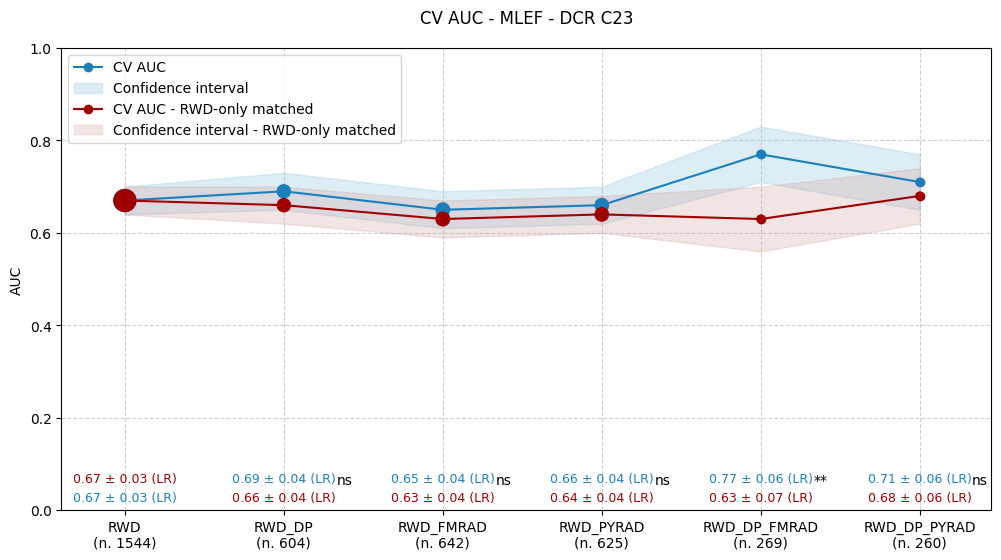

In [103]:
plot_auc_results(
    architecture="MLEF",
    outcome="DCR",
    analyses=["C23"],
    modality_order=[
        "RWD",
        "RWD_DP",
        "RWD_FMRAD",
        "RWD_PYRAD",
        "RWD_DP_FMRAD",
        "RWD_DP_PYRAD"
    ],
    exclude_modalities=("DP", "FMRAD", "PYRAD"),
    title_prefix=None,
    min_bubble=30,
    max_bubble=250,
    show=True,
    save_dir=None
)

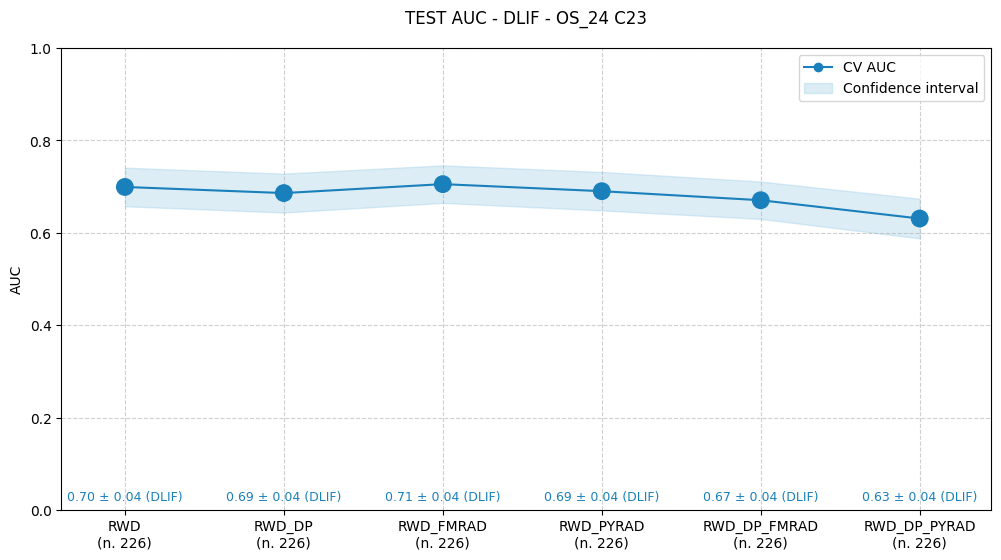

In [93]:
plot_auc_results(
    architecture="DLIF",
    outcome="OS_24",
    analyses=["C23"],
    modality_order=[
        "RWD",
        "RWD_DP",
        "RWD_FMRAD",
        "RWD_PYRAD",
        "RWD_DP_FMRAD",
        "RWD_DP_PYRAD"
    ],
    exclude_modalities=("DP", "FMRAD", "PYRAD", "RWD_RADFM_DP_GENOMICS", "RWD_RADPY_DP_GENOMICS"),
    title_prefix='TEST AUC - DLIF',
    min_bubble=30,
    max_bubble=250,
    show=True,
    save_dir=None,
    use_preds = use_preds
)

# BIOMARKER COMPARISON SPIDER PLOT

run this section to reproduce **figure 3** biomarker comparison graphs

Thresholds used to calculate biomarkers: (biomarker >= threshold will be convert into class 1)
- PDL1: 
    - 1 for OS 6, DCR (PDL1 >= 1%); 2 for OS 24 (PDL1 >= 50%)
- NLR: 4
- LDH: 400
- ECOG: 2

Take the real values of the biomarker, remove the missing ones.
According to the outcome (DCR/OS6/OS24) the biomarker will be converted into TP, FP, TN, FN.
Then calculate AUC, accuracy, sensitivity, specificity using as y_true the outcome and y_pred the biomarker.
On the same subset of patients, for each biomarker, use the model to compute the metrics

In [16]:
outcome = 'OS_24' #or 'OS_6' or 'DCR'
modality = 'RWD'

In [17]:
rwd = pd.read_csv('data/rwd.csv')
outcomes = pd.read_csv('data/outcomes.csv')
rwd = rwd.merge(outcomes, on='Subject', how='inner')
test = rwd[rwd['SET'] == 'TEST']
test = test[test[outcome].notna()].reset_index(drop=True)
test.set_index('Subject', inplace=True)
y_pred_mlef = pd.read_csv(f'mlef_pipeline/results/{outcome}/C23/{modality}/prediction_TEST.csv')

In [18]:
if outcome == 'OS_24':
    bio_pdl1 = 'BIO_PDL1_50'
else:
    bio_pdl1 = 'BIO_PDL1_1'

test_biomarkers, biomarkers = add_single_biomarkers(
    outcome=outcome,
    df=test,
    to_show=[bio_pdl1, 'BIO_NLR', 'BIO_LDH', 'BIO_ECOG']
)
test_biomarkers = convert_to_binary(test_biomarkers, biomarkers)
test_biomarkers[[bio_pdl1, 'binary_' + bio_pdl1, 'BIO_NLR', 'binary_BIO_NLR', 'BIO_LDH', 'binary_BIO_LDH', 'BIO_ECOG', 'binary_BIO_ECOG']]

,BIO_PDL1_50,binary_BIO_PDL1_50,BIO_NLR,binary_BIO_NLR,BIO_LDH,binary_BIO_LDH,BIO_ECOG,binary_BIO_ECOG
Subject,,,,,,,,
9,FP,1.0,TN,0.0,TN,0.0,NaN,NaN
14,FP,1.0,TN,0.0,FP,1.0,NaN,NaN
16,TN,0.0,FP,1.0,FP,1.0,NaN,NaN
17,TN,0.0,FP,1.0,FP,1.0,FP,1.0
19,TN,0.0,FP,1.0,FP,1.0,FP,1.0
...,...,...,...,...,...,...,...,...
2059,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0
2063,TN,0.0,FP,1.0,NaN,NaN,FP,1.0
2065,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0


In [19]:
#compute metrics for each biomarker
biomarker_results = {}
for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    bio = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio.reset_index(drop=True, inplace=True)
    metrics = compute_metrics_biomarker(bio[outcome], bio[biomarker])
    metrics['n.patients'] = len(bio)
    biomarker_results[biomarker] = metrics
    print(f"Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")


Metrics for binary_BIO_PDL1_50:
AUC: 0.5317, Accuracy: 0.6257, Sensitivity: 0.3333, Specificity: 0.7302

Metrics for binary_BIO_NLR:
AUC: 0.6560, Accuracy: 0.6700, Sensitivity: 0.6275, Specificity: 0.6846

Metrics for binary_BIO_LDH:
AUC: 0.5815, Accuracy: 0.4481, Sensitivity: 0.8837, Specificity: 0.2793

Metrics for binary_BIO_ECOG:
AUC: 0.6177, Accuracy: 0.4515, Sensitivity: 0.9821, Specificity: 0.2533



In [20]:
#compute model metrics on biomarkers subset

mlef_model_results = {}
patients = {}
for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    bio = test_biomarkers[test_biomarkers[biomarker].notna()].index
    print(f"Testing model on n. {len(bio)} patients...")
    
    y_pred_bio = y_pred_mlef[y_pred_mlef['Subject'].isin(bio)]['y_pred'].values
    y_proba_bio = y_pred_mlef[y_pred_mlef['Subject'].isin(bio)]['y_proba'].values
    y_true_bio = y_pred_mlef[y_pred_mlef['Subject'].isin(bio)]['y_true'].values
    metrics = compute_metrics(y_true_bio, y_pred_bio, y_proba_bio)
    metrics['n.patients'] = len(bio)
    patients[biomarker] = bio.tolist()
    mlef_model_results[biomarker] = metrics
    print(f"Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")


Testing model on n. 171 patients...
Metrics for binary_BIO_PDL1_50:
AUC: 0.7447, Accuracy: 0.5906, Sensitivity: 0.8889, Specificity: 0.4841

Testing model on n. 200 patients...
Metrics for binary_BIO_NLR:
AUC: 0.7600, Accuracy: 0.6100, Sensitivity: 0.8627, Specificity: 0.5235

Testing model on n. 154 patients...
Metrics for binary_BIO_LDH:
AUC: 0.7529, Accuracy: 0.6104, Sensitivity: 0.8837, Specificity: 0.5045

Testing model on n. 206 patients...
Metrics for binary_BIO_ECOG:
AUC: 0.7476, Accuracy: 0.6019, Sensitivity: 0.8393, Specificity: 0.5133



In [21]:

# Apply DeLong test to compare biomarkers vs ML model
delong_mlef_results = {}

for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    print(f"\n=== DeLong Test for {biomarker} vs ML Model ===")
    
    # Get subset of data where biomarker is available
    bio_subset = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio_subjects = bio_subset.index
    
    # Get corresponding test data and model predictions
    test_bio = test[test.index.isin(bio_subjects)]
    y_true_bio = test_bio[outcome].values
    
    # Biomarker predictions (binary, so we use them as probabilities)
    biomarker_preds = bio_subset.loc[test_bio.index, biomarker].values
    
    # ML model predictions (probabilities)
    ml_model_preds = y_pred_mlef[y_pred_mlef['Subject'].isin(bio_subjects)]['y_proba'].values
    
    # Perform DeLong test
    delong_result = delong_test_comparison(y_true_bio, biomarker_preds, ml_model_preds)
    delong_mlef_results[biomarker] = delong_result
    
    # Print results
    print(f"Biomarker AUC: {delong_result['auc1']:.4f} (95% CI: {delong_result['auc1_ci'][0]:.4f}-{delong_result['auc1_ci'][1]:.4f})")
    print(f"ML Model AUC: {delong_result['auc2']:.4f} (95% CI: {delong_result['auc2_ci'][0]:.4f}-{delong_result['auc2_ci'][1]:.4f})")
    print(f"AUC Difference: {delong_result['auc_difference']:.4f}")
    print(f"Z-score: {delong_result['z_score']:.4f}")
    print(f"P-value: {delong_result['p_value']:.6f}")
    print(f"Statistically significant (p < 0.05): {'Yes' if delong_result['significant'] else 'No'}")
    
    if delong_result['significant']:
        if delong_result['auc_difference'] > 0:
            print("→ Biomarker performs significantly better than ML model")
        else:
            print("→ ML model performs significantly better than biomarker")
    else:
        print("→ No significant difference between biomarker and ML model")


=== DeLong Test for binary_BIO_PDL1_50 vs ML Model ===
Biomarker AUC: 0.5317 (95% CI: 0.4520-0.6115)
ML Model AUC: 0.7447 (95% CI: 0.6625-0.8269)
AUC Difference: -0.2130
Z-score: -3.7009
P-value: 0.000215
Statistically significant (p < 0.05): Yes
→ ML model performs significantly better than biomarker

=== DeLong Test for binary_BIO_NLR vs ML Model ===
Biomarker AUC: 0.6560 (95% CI: 0.5793-0.7328)
ML Model AUC: 0.7600 (95% CI: 0.6827-0.8373)
AUC Difference: -0.1040
Z-score: -3.1261
P-value: 0.001772
Statistically significant (p < 0.05): Yes
→ ML model performs significantly better than biomarker

=== DeLong Test for binary_BIO_LDH vs ML Model ===
Biomarker AUC: 0.5815 (95% CI: 0.5174-0.6456)
ML Model AUC: 0.7529 (95% CI: 0.6691-0.8367)
AUC Difference: -0.1714
Z-score: -3.3060
P-value: 0.000946
Statistically significant (p < 0.05): Yes
→ ML model performs significantly better than biomarker

=== DeLong Test for binary_BIO_ECOG vs ML Model ===
Biomarker AUC: 0.6177 (95% CI: 0.5787-0.656

In [22]:
delong_mlef_summary = []
for biomarker, result in delong_mlef_results.items():
    biomarker_name = biomarker.replace('binary_BIO_', '')
    
    delong_mlef_summary.append({
        'Biomarker': biomarker_name,
        'Biomarker_AUC': f"{result['auc1']:.3f}",
        'Biomarker_CI': f"({result['auc1_ci'][0]:.3f}-{result['auc1_ci'][1]:.3f})",
        'ML_Model_AUC': f"{result['auc2']:.3f}",
        'ML_Model_CI': f"({result['auc2_ci'][0]:.3f}-{result['auc2_ci'][1]:.3f})",
        'AUC_Difference': f"{result['auc_difference']:.3f}",
        'P_value': f"{result['p_value']:.6f}",
        'Significant': 'Yes' if result['significant'] else 'No',
        'Better_Model': 'Biomarker' if result['auc_difference'] > 0 and result['significant'] 
                       else 'ML Model' if result['auc_difference'] < 0 and result['significant']
                       else 'No difference'
    })

delong_mlef = pd.DataFrame(delong_mlef_summary)
print("\n=== DeLong Test Summary (MLEF) ===")
print(delong_mlef.to_string(index=False))



=== DeLong Test Summary (MLEF) ===
Biomarker Biomarker_AUC  Biomarker_CI ML_Model_AUC   ML_Model_CI AUC_Difference  P_value Significant Better_Model
  PDL1_50         0.532 (0.452-0.612)        0.745 (0.663-0.827)         -0.213 0.000215         Yes     ML Model
      NLR         0.656 (0.579-0.733)        0.760 (0.683-0.837)         -0.104 0.001772         Yes     ML Model
      LDH         0.582 (0.517-0.646)        0.753 (0.669-0.837)         -0.171 0.000946         Yes     ML Model
     ECOG         0.618 (0.579-0.657)        0.748 (0.671-0.824)         -0.130 0.001826         Yes     ML Model


In [23]:
biomarker_scores = {
    'PDL1': {k: round(v, 2) for k, v in biomarker_results['binary_' + bio_pdl1].items()},
    'NLR': {k: round(v, 2) for k, v in biomarker_results['binary_BIO_NLR'].items()},
    'LDH': {k: round(v, 2) for k, v in biomarker_results['binary_BIO_LDH'].items()},
    'ECOG': {k: round(v, 2) for k, v in biomarker_results['binary_BIO_ECOG'].items()},
}
mlef_model_scores = {
    'PDL1': {k: round(v, 2) for k, v in mlef_model_results['binary_' + bio_pdl1].items()},
    'NLR': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_NLR'].items()},
    'LDH': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_LDH'].items()},
    'ECOG': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_ECOG'].items()}
}
p_values_mlef = [float(delong_mlef[delong_mlef['Biomarker'] == biomarker]['P_value'].values[0]) for biomarker in ['PDL1_50', 'NLR', 'LDH', 'ECOG']]
size = [
    biomarker_results['binary_' + bio_pdl1]['n.patients'],
    biomarker_results['binary_BIO_NLR']['n.patients'],
    biomarker_results['binary_BIO_LDH']['n.patients'],
    biomarker_results['binary_BIO_ECOG']['n.patients']
]

In [24]:
# Load DLIF model predictions from parquet file
from sklearn.metrics import roc_auc_score
import numpy as np

# use best performing multimodal DLIF model:
# - OS 24: RWD FMRAD
# - OS 6: RWD
# - DCR: RWD DP FMRAD

modality = 'RWD_FMRAD' 

outcome_dlif = outcome_to_dlif(outcome)
modality_dlif = map_mlef_to_dlif_modality(modality)

if use_preds:
    predictions_df = pd.read_parquet(f'dlif_pipeline/preds/{outcome_dlif}/classification/standard/{modality_dlif}/predictions.parquet')
else:
    predictions_df = pd.read_parquet(f'dlif_pipeline/results/C23/{outcome_dlif}/classification/standard/hypothesis_driven/pyrad-noimp/{modality_dlif}/seed_0/eval/00000-mb_attention_mil/predictions.parquet')

# Convert non-softmaxed predictions to probabilities using softmax
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# Apply softmax to get probabilities
logits = predictions_df[['y_pred0', 'y_pred1']].values
probabilities = softmax(logits)
predictions_df['y_pred_proba'] = probabilities[:, 1]  # Probability of positive class

print(f'Loaded predictions for {len(predictions_df)} patients')
print(f'AUC from loaded predictions: {roc_auc_score(predictions_df["y_true"], predictions_df["y_pred_proba"]):.4f}')



Loaded predictions for 226 patients
AUC from loaded predictions: 0.7055


In [25]:
# Set up data from DLIF pipeline
annotations = pd.read_csv('data/annotations.csv')
outcome_col_name = "dataset_" + outcome_dlif
test_set = annotations[annotations[outcome_col_name]=='test']['slide'].tolist()

test = rwd[rwd['Subject'].isin(test_set)]
test = test[test[outcome].notna()].reset_index(drop=True)
test.set_index('Subject', inplace=True)
y_pred_dlif = predictions_df.copy()
test

,CENTER,SET,AGE AT DIAGNOSIS,AGE AT IO START,SEX,ECOG PS,SMOKING CURRENT,SMOKING FORMER,SMOKING NEVER,EVER SMOKED,...,IO IOCHT_y,HISTOLOGY SQUAMOUS_y,ORR,DCR,CBR,PFS MONTHS,OS MONTHS,TTF MONTHS,OS_6,OS_24
Subject,,,,,,,,,,,,,,,,,,,,,
9,GHD,TEST,<67,<62,0,NaN,0.0,0.0,1.0,0.0,...,0,0.0,0.0,0.0,0.0,2.923784,6.701708,2.036794,1.0,0.0
14,GHD,TEST,67-74,>69,1,NaN,0.0,1.0,0.0,1.0,...,1,0.0,0.0,0.0,0.0,8.212878,8.212878,3.942181,1.0,0.0
16,GHD,TEST,>74,>69,0,NaN,1.0,0.0,0.0,1.0,...,1,0.0,0.0,0.0,0.0,1.905388,1.905388,1.314060,0.0,0.0
17,GHD,TEST,<67,<62,0,1.0,1.0,0.0,0.0,1.0,...,1,0.0,0.0,0.0,0.0,2.956636,8.344284,2.431012,1.0,0.0
19,GHD,TEST,<67,<62,1,0.0,0.0,1.0,0.0,1.0,...,1,0.0,1.0,1.0,1.0,5.486202,20.926413,5.847569,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2059,VHIO,TEST,<67,62-69,1,1.0,1.0,0.0,0.0,1.0,...,0,0.0,0.0,0.0,0.0,1.018397,1.576873,0.361367,0.0,0.0
2063,VHIO,TEST,67-74,>69,1,1.0,1.0,0.0,0.0,1.0,...,0,0.0,0.0,0.0,0.0,0.788436,0.919842,0.459921,0.0,0.0
2065,VHIO,TEST,<67,<62,1,1.0,1.0,0.0,0.0,1.0,...,0,1.0,0.0,0.0,0.0,1.084100,3.876478,0.886991,0.0,0.0


In [26]:
if outcome == 'OS_24':
    bio_pdl1 = 'BIO_PDL1_50'
else:
    bio_pdl1 = 'BIO_PDL1_1'

test_biomarkers, biomarkers = add_single_biomarkers(
    outcome=outcome,
    df=test,
    to_show=[bio_pdl1, 'BIO_NLR', 'BIO_LDH', 'BIO_ECOG']
)
print("test_biomarkers columns:", test_biomarkers.columns.tolist())
print("biomarkers list:", biomarkers)

test_biomarkers = convert_to_binary(test_biomarkers, biomarkers)
test_biomarkers[[bio_pdl1, 'binary_' + bio_pdl1, 'BIO_NLR', 'binary_BIO_NLR', 'BIO_LDH', 'binary_BIO_LDH', 'BIO_ECOG', 'binary_BIO_ECOG']]

test_biomarkers columns: ['CENTER', 'SET', 'AGE AT DIAGNOSIS', 'AGE AT IO START', 'SEX', 'ECOG PS', 'SMOKING CURRENT', 'SMOKING FORMER', 'SMOKING NEVER', 'EVER SMOKED', 'SMOKING PACKYEAR CUTOFF 10', 'SMOKING PACKSYEAR', 'HISTOLOGY ADENOCARCINOMA', 'HISTOLOGY SQUAMOUS_x', 'HISTOLOGY OTHER', 'PDL1 CATEGORY', 'T DIAGNOSIS', 'N DIAGNOSIS', 'M DIAGNOSIS', 'DIAG STAGE', 'T AT IO START', 'N AT IO START', 'M AT IO START', 'IO LINE_x', 'RACE', 'STAGE AT IO START', 'PARENCHYMAL BRAIN METS AT IO START', 'LIVER METS AT IO START', 'BONE METS AT IO START', 'ADRENAL METS AT IO START', 'BONE MARROW METS AT IO START', 'LEPTOMENINGEAL METS AT IO START', 'LUNG METS AT IO START', 'LYMPH NODES METS AT IO START', 'PERICARDIAL EFFUSION METS AT IO START', 'PLEURA METS AT IO START', 'PLEURAL EFFUSION METS AT IO START', 'SKIN METS AT IO START', 'SOFT TISSUE METS AT IO START', 'OTHER METS AT IO START', 'SURGERY', 'LDH', 'NEUTROPHYL', 'MONOCYTE', 'LYMPHOCYTES', 'NLR', 'BMI', 'IO IOCHT_x', 'IO IN NEOADJUVANT', 'TA

,BIO_PDL1_50,binary_BIO_PDL1_50,BIO_NLR,binary_BIO_NLR,BIO_LDH,binary_BIO_LDH,BIO_ECOG,binary_BIO_ECOG
Subject,,,,,,,,
9,FP,1.0,TN,0.0,TN,0.0,NaN,NaN
14,FP,1.0,TN,0.0,FP,1.0,NaN,NaN
16,TN,0.0,FP,1.0,FP,1.0,NaN,NaN
17,TN,0.0,FP,1.0,FP,1.0,FP,1.0
19,TN,0.0,FP,1.0,FP,1.0,FP,1.0
...,...,...,...,...,...,...,...,...
2059,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0
2063,TN,0.0,FP,1.0,NaN,NaN,FP,1.0
2065,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0


In [27]:
#compute metrics for each biomarker
results = {}
for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    bio = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio.reset_index(drop=True, inplace=True)
    metrics = compute_metrics_biomarker(bio[outcome], bio[biomarker])
    metrics['n.patients'] = len(bio)
    results[biomarker] = metrics
    print(f"Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")


Metrics for binary_BIO_PDL1_50:
AUC: 0.5317, Accuracy: 0.6257, Sensitivity: 0.3333, Specificity: 0.7302

Metrics for binary_BIO_NLR:
AUC: 0.6560, Accuracy: 0.6700, Sensitivity: 0.6275, Specificity: 0.6846

Metrics for binary_BIO_LDH:
AUC: 0.5815, Accuracy: 0.4481, Sensitivity: 0.8837, Specificity: 0.2793

Metrics for binary_BIO_ECOG:
AUC: 0.6177, Accuracy: 0.4515, Sensitivity: 0.9821, Specificity: 0.2533



In [28]:
# Test DLIF model predictions on biomarkers subset using loaded predictions from parquet
dl_model_results = {}
patients = {}

for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    # Get patients where biomarker is available
    bio_patients = test_biomarkers[test_biomarkers[biomarker].notna()].index
    print(f"Testing DLIF model on n. {len(bio_patients)} patients...")
    
    # Match with predictions data using slide column
    predictions_subset = predictions_df[predictions_df['slide'].isin(bio_patients)]
    
    # Get true labels and predicted probabilities
    y_true_bio = predictions_subset['y_true'].values
    y_proba_bio = predictions_subset['y_pred_proba'].values
    y_pred_bio = (y_proba_bio >= 0.5).astype(int)
    
    # Calculate metrics
    metrics = compute_metrics(y_true_bio, y_pred_bio, y_proba_bio)
    metrics['n.patients'] = len(predictions_subset)
    patients[biomarker] = bio_patients.tolist()
    dl_model_results[biomarker] = metrics
    
    print(f"DLIF Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")

Testing DLIF model on n. 171 patients...
DLIF Metrics for binary_BIO_PDL1_50:
AUC: 0.6963, Accuracy: 0.5497, Sensitivity: 0.7778, Specificity: 0.4683

Testing DLIF model on n. 200 patients...
DLIF Metrics for binary_BIO_NLR:
AUC: 0.7242, Accuracy: 0.6150, Sensitivity: 0.7843, Specificity: 0.5570

Testing DLIF model on n. 154 patients...
DLIF Metrics for binary_BIO_LDH:
AUC: 0.7379, Accuracy: 0.6104, Sensitivity: 0.8140, Specificity: 0.5315

Testing DLIF model on n. 206 patients...
DLIF Metrics for binary_BIO_ECOG:
AUC: 0.7199, Accuracy: 0.6165, Sensitivity: 0.8036, Specificity: 0.5467



In [29]:
# Apply DeLong test to compare biomarkers vs DLIF model using loaded predictions
delong_results_dl = {}

for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    print(f"\n=== DeLong Test for {biomarker} vs DLIF Model ===")
    
    # Get subset of data where biomarker is available
    bio_subset = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio_subjects = bio_subset.index
    # Get corresponding predictions data
    predictions_subset = predictions_df[predictions_df['slide'].isin(bio_subjects)]
    # Match biomarker data with predictions by Subject/slide
    merged_data = bio_subset.merge(predictions_subset, left_on='Subject', right_on='slide', how='inner')
    
    y_true_bio = merged_data['y_true'].values
    
    # Biomarker predictions (binary, so we use them as probabilities)  
    biomarker_preds = merged_data[biomarker].values
    
    # DLIF model predictions (probabilities)
    dl_model_preds = merged_data['y_pred_proba'].values
    # Perform DeLong test
    delong_result = delong_test_comparison(y_true_bio, biomarker_preds, dl_model_preds)
    delong_results_dl[biomarker] = delong_result
    
    # Print results
    print(f"Biomarker AUC: {delong_result['auc1']:.4f} (95% CI: {delong_result['auc1_ci'][0]:.4f}-{delong_result['auc1_ci'][1]:.4f})")
    print(f"DLIF Model AUC: {delong_result['auc2']:.4f} (95% CI: {delong_result['auc2_ci'][0]:.4f}-{delong_result['auc2_ci'][1]:.4f})")
    print(f"AUC Difference: {delong_result['auc_difference']:.4f}")
    print(f"Z-score: {delong_result['z_score']:.4f}")
    print(f"P-value: {delong_result['p_value']:.6f}")
    print(f"Statistically significant (p < 0.05): {'Yes' if delong_result['significant'] else 'No'}")
    
    if delong_result['significant']:
        if delong_result['auc_difference'] > 0:
            print("→ Biomarker performs significantly better than DLIF model")
        else:
            print("→ DLIF model performs significantly better than biomarker")
    else:
        print("→ No significant difference between biomarker and DLIF model")


=== DeLong Test for binary_BIO_PDL1_50 vs DLIF Model ===
Biomarker AUC: 0.5317 (95% CI: 0.4520-0.6115)
DLIF Model AUC: 0.6963 (95% CI: 0.6016-0.7910)
AUC Difference: -0.1646
Z-score: -2.8847
P-value: 0.003918
Statistically significant (p < 0.05): Yes
→ DLIF model performs significantly better than biomarker

=== DeLong Test for binary_BIO_NLR vs DLIF Model ===
Biomarker AUC: 0.6560 (95% CI: 0.5793-0.7328)
DLIF Model AUC: 0.7242 (95% CI: 0.6404-0.8079)
AUC Difference: -0.0682
Z-score: -1.3466
P-value: 0.178101
Statistically significant (p < 0.05): No
→ No significant difference between biomarker and DLIF model

=== DeLong Test for binary_BIO_LDH vs DLIF Model ===
Biomarker AUC: 0.5815 (95% CI: 0.5174-0.6456)
DLIF Model AUC: 0.7379 (95% CI: 0.6501-0.8257)
AUC Difference: -0.1564
Z-score: -2.9954
P-value: 0.002740
Statistically significant (p < 0.05): Yes
→ DLIF model performs significantly better than biomarker

=== DeLong Test for binary_BIO_ECOG vs DLIF Model ===
Biomarker AUC: 0.6177

In [30]:
# Create a summary table of DeLong test results for DLIF model
delong_summary_dl = []
for biomarker, result in delong_results_dl.items():
    biomarker_name = biomarker.replace('binary_BIO_', '')
    
    delong_summary_dl.append({
        'Biomarker': biomarker_name,
        'Biomarker_AUC': f"{result['auc1']:.3f}",
        'Biomarker_CI': f"({result['auc1_ci'][0]:.3f}-{result['auc1_ci'][1]:.3f})",
        'DLIF_Model_AUC': f"{result['auc2']:.3f}",
        'DLIF_Model_CI': f"({result['auc2_ci'][0]:.3f}-{result['auc2_ci'][1]:.3f})",
        'AUC_Difference': f"{result['auc_difference']:.3f}",
        'P_value': f"{result['p_value']:.6f}",
        'Significant': 'Yes' if result['significant'] else 'No',
        'Better_Model': 'Biomarker' if result['auc_difference'] > 0 and result['significant'] 
                       else 'DLIF Model' if result['auc_difference'] < 0 and result['significant']
                       else 'No difference'
    })

delong_df_dl = pd.DataFrame(delong_summary_dl)
print("\n=== DeLong Test Summary (DLIF) ===")
print(delong_df_dl.to_string(index=False))


=== DeLong Test Summary (DLIF) ===
Biomarker Biomarker_AUC  Biomarker_CI DLIF_Model_AUC DLIF_Model_CI AUC_Difference  P_value Significant  Better_Model
  PDL1_50         0.532 (0.452-0.612)          0.696 (0.602-0.791)         -0.165 0.003918         Yes    DLIF Model
      NLR         0.656 (0.579-0.733)          0.724 (0.640-0.808)         -0.068 0.178101          No No difference
      LDH         0.582 (0.517-0.646)          0.738 (0.650-0.826)         -0.156 0.002740         Yes    DLIF Model
     ECOG         0.618 (0.579-0.657)          0.720 (0.641-0.799)         -0.102 0.013467         Yes    DLIF Model


In [31]:
# DLIF model scores 
dlif_scores = {
    'PDL1': {k: round(v, 2) for k, v in dl_model_results['binary_' + bio_pdl1].items()},
    'NLR': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_NLR'].items()},
    'LDH': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_LDH'].items()},
    'ECOG': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_ECOG'].items()}
}

p_values_dl = [float(delong_df_dl[delong_df_dl['Biomarker'] == biomarker]['P_value'].values[0]) for biomarker in ['PDL1_50', 'NLR', 'LDH', 'ECOG']]  # DLIF p-values

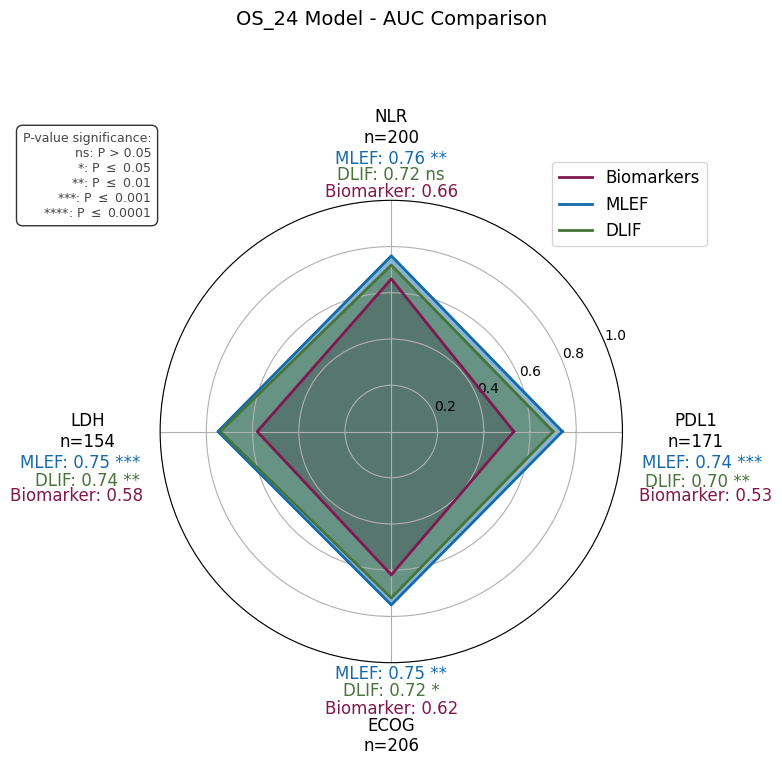

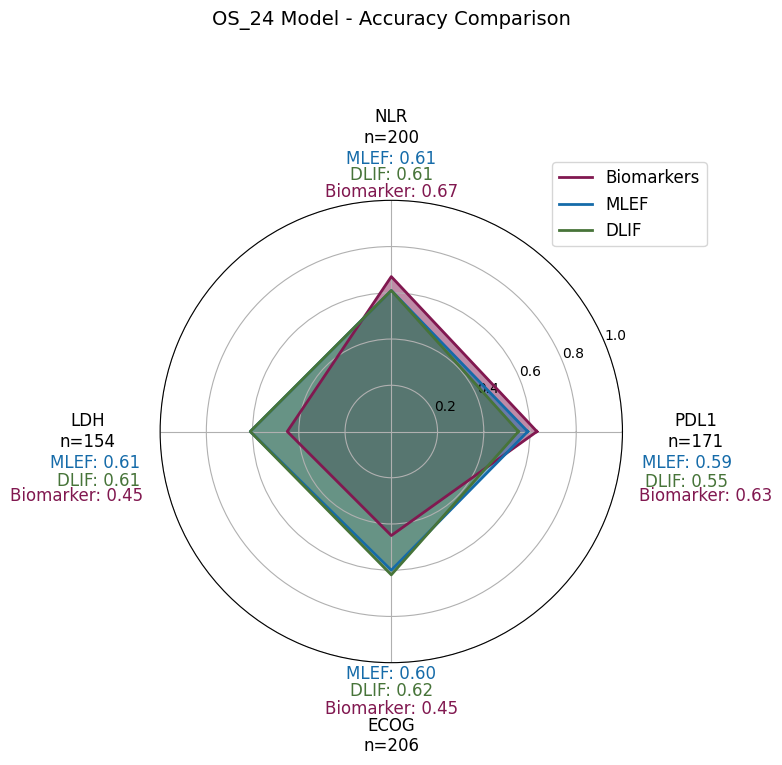

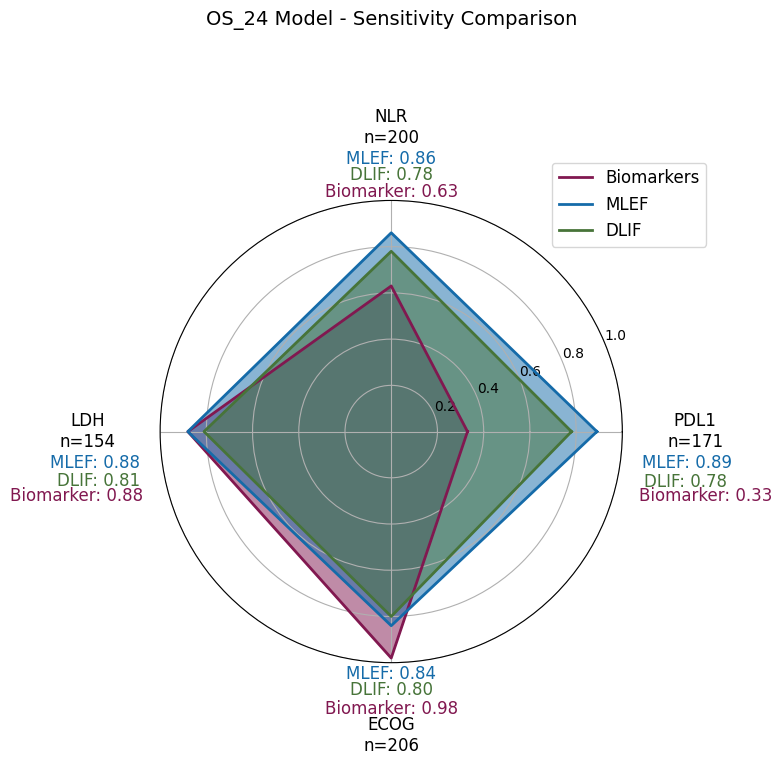

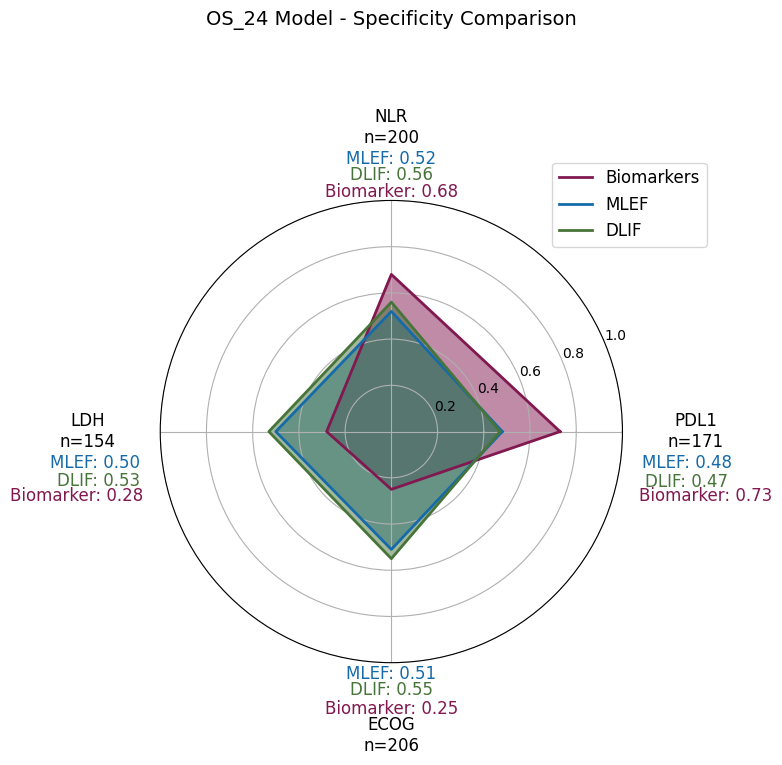

In [32]:
biomarkers = ['PDL1', 'NLR', 'LDH', 'ECOG']

metrics = ['AUC', 'Accuracy', 'Sensitivity', 'Specificity']
plot_radar_charts(
    biomarker_scores=biomarker_scores,
    model_scores=mlef_model_scores,
    dl_scores=dlif_scores,
    p_values_ml=p_values_mlef,
    p_values_dl=p_values_dl,
    size=size,
    biomarkers=biomarkers,
    metrics=metrics,
    title_prefix=f'{outcome} Model'
)


# FARINESS RESULTS PLOT

run this section to reproduce **figure 4** fairness graphs

In [73]:
# Configuration for each outcome
# Predictions are loaded from: mlef_pipeline/results/{outcome}/C23/RWD/prediction_TEST.csv
OUTCOME_CONFIG = {
    'OS 24': {
        'outcome': 'OS_24',
        'outcome_name': 'OS 24'
    },
     'OS 6': {
        'outcome': 'OS_6',
        'outcome_name': 'OS 6'
    },
    'DCR': {
        'outcome': 'DCR',              
        'outcome_name': 'DCR'         
    }
    
}

# Base path where MLEF folder is located
BASE_PATH = 'mlef_pipeline/results'

# These will be computed automatically from the data
PATIENTS_PER_OUTCOME = {}
OUTCOME_THRESHOLDS_TPR = {}
OUTCOME_THRESHOLDS_FPR = {}

In [ ]:
# Run analysis for all outcomes
all_results = {}

for outcome_display_name, config in OUTCOME_CONFIG.items():
    results = analyze_outcome_fairness(
        outcome=config['outcome'],
        outcome_name=config['outcome_name'],
        base_path=BASE_PATH,
        n_perms=1000,
        random_state=42,
        set = 'TEST'
    )
    all_results[outcome_display_name] = results
    
    # Populate thresholds and patient counts automatically
    OUTCOME_THRESHOLDS_TPR[outcome_display_name] = results['threshold_tpr']
    OUTCOME_THRESHOLDS_FPR[outcome_display_name] = results['threshold_fpr']
    PATIENTS_PER_OUTCOME[outcome_display_name] = results['patients_per_center']

print("\n" + "="*60)
print("Analysis completed for all outcomes!")
print("="*60)
print("\nComputed Thresholds:")
print(f"  TPR: {OUTCOME_THRESHOLDS_TPR}")
print(f"  FPR: {OUTCOME_THRESHOLDS_FPR}")
print(f"\nPatients per outcome (by center):")
for outcome, counts in PATIENTS_PER_OUTCOME.items():
    print(f"  {outcome}: {counts}")


Analyzing OS 24

Loaded predictions for OS_24:
  Samples: 226
  Columns in test data: 3 (CENTER, SEX, RACE)
  Subject order preserved: True
Overall Test Performance:
  AUC: 0.675
  TPR (threshold): 0.850
  FPR (threshold): 0.500

Analyzing fairness by center...
Patients per center: {'INT': 97, 'GHD': 63, 'VHIO': 29, 'SZMC': 20, 'MH': 17}
Patients per sex: {1: 141, 0: 85}


Sex-based fairness analysis (test set)...
  TPR - Female: 0.960, Male: 0.771, p=0.0539
  FPR - Female: 0.550, Male: 0.472, p=0.3407

Center-based fairness analysis...
  TPR omnibus p-value: 0.1239
  FPR omnibus p-value: 0.3876

Analyzing OS 6

Loaded predictions for OS_6:
  Samples: 259
  Columns in test data: 3 (CENTER, SEX, RACE)
  Subject order preserved: True
Overall Test Performance:
  AUC: 0.642
  TPR (threshold): 0.648
  FPR (threshold): 0.364

Analyzing fairness by center...
Patients per center: {'INT': 101, 'GHD': 65, 'SZMC': 36, 'VHIO': 31, 'MH': 26}
Patients per sex: {1: 166, 0: 93}


Sex-based fairness a

In [24]:
# Create summary tables
sex_fairness, center_fairness, pairwise_tpr, pairwise_fpr = create_fairness_summary(all_results)

print("Sex-based fairness summary:")
display(sex_fairness)

print("\nCenter-based fairness summary:")
display(center_fairness)

Sex-based fairness summary:


,Metric,Sex,Value,CI,p-value,outcome
0,TPR,Female,0.960000,"(0.88, 1.0)",0.053946,OS 24
1,TPR,Male,0.771429,"(0.63, 0.91)",0.053946,OS 24
2,FPR,Female,0.550000,"(0.43, 0.68)",0.340659,OS 24
3,FPR,Male,0.471698,"(0.37, 0.57)",0.340659,OS 24
4,TPR,Female,0.714286,"(0.6, 0.83)",0.203796,OS 6
5,TPR,Male,0.613445,"(0.53, 0.71)",0.203796,OS 6
6,FPR,Female,0.433333,"(0.27, 0.6)",0.317682,OS 6
7,FPR,Male,0.319149,"(0.19, 0.45)",0.317682,OS 6
8,TPR,Female,0.796610,"(0.68, 0.9)",0.150849,DCR
9,TPR,Male,0.681818,"(0.59, 0.77)",0.150849,DCR



Center-based fairness summary:


,TPR,TPR_ci_lower,TPR_ci_upper,FPR,FPR_ci_lower,FPR_ci_upper,outcome,TPR_omnibus_p,FPR_omnibus_p
center,,,,,,,,,
GHD,0.875000,0.62,1.00,0.545455,0.40,0.67,OS 24,0.123876,0.387612
GHD,0.619048,0.48,0.74,0.565217,0.35,0.74,OS 6,0.015984,0.033966
GHD,0.727273,0.58,0.88,0.531250,0.34,0.69,DCR,0.023976,0.119880
INT,0.833333,0.70,0.97,0.417910,0.30,0.54,OS 24,0.123876,0.387612
INT,0.578125,0.45,0.69,0.270270,0.14,0.41,OS 6,0.015984,0.033966
INT,0.631579,0.51,0.75,0.318182,0.18,0.45,DCR,0.023976,0.119880
MH,1.000000,1.00,1.00,0.666667,0.33,0.89,OS 24,0.123876,0.387612
MH,0.958333,0.88,1.00,0.500000,0.00,1.00,OS 6,0.015984,0.033966
MH,0.964286,0.89,1.00,0.714286,0.29,1.00,DCR,0.023976,0.119880


Failed to add labels: 'ErrorbarContainer' object has no attribute 'patches'


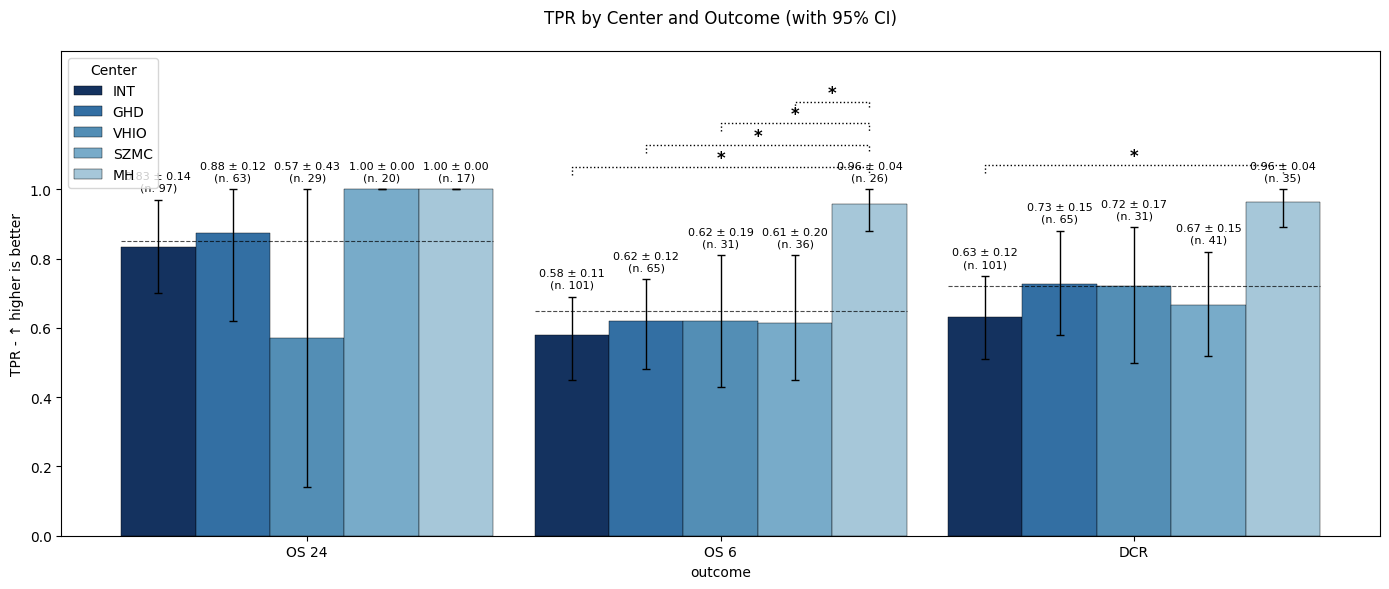

In [25]:
# Plot TPR by center
plot_fairness_by_center(
    center_fairness=center_fairness,
    pairwise_tpr=pairwise_tpr,
    pairwise_fpr=pairwise_fpr,
    metric='TPR',
    patients_per_outcome=PATIENTS_PER_OUTCOME,
    outcome_thresholds=OUTCOME_THRESHOLDS_TPR
)

Failed to add labels: 'ErrorbarContainer' object has no attribute 'patches'


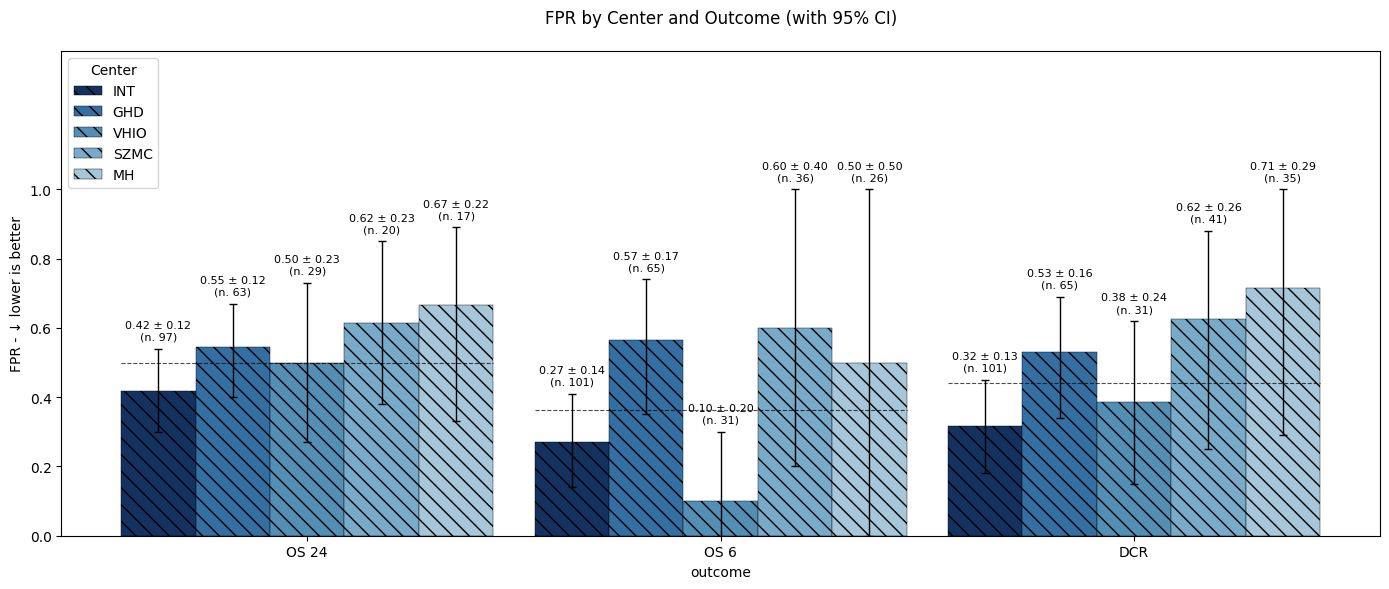

In [26]:
# Plot FPR by center
plot_fairness_by_center(
    center_fairness=center_fairness,
    pairwise_tpr=pairwise_tpr,
    pairwise_fpr=pairwise_fpr,
    metric='FPR',
    patients_per_outcome=PATIENTS_PER_OUTCOME,
    outcome_thresholds=OUTCOME_THRESHOLDS_FPR
)

Patients per sex:
  OS 24: {'Female': 85, 'Male': 141}
  OS 6: {'Female': 93, 'Male': 166}
  DCR: {'Female': 98, 'Male': 175}
Failed to add labels: 'ErrorbarContainer' object has no attribute 'patches'


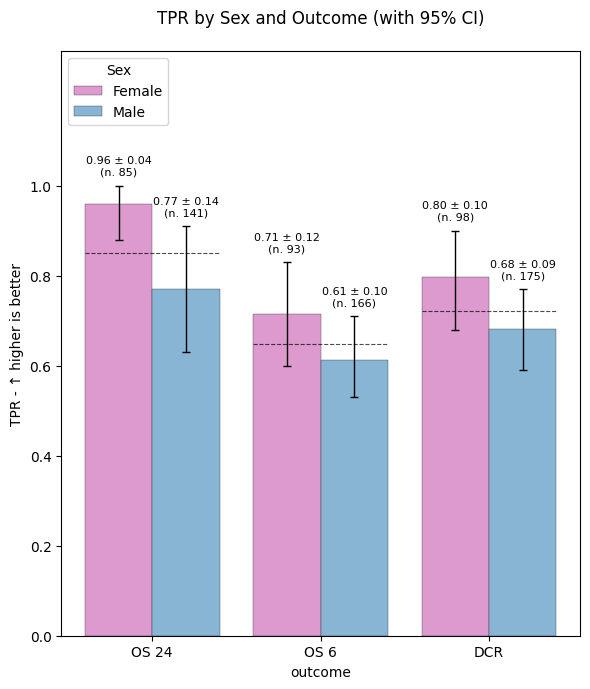

In [27]:
# Compute sex patient counts from results
sex_patients = {}
for outcome_name, results in all_results.items():
    sex_counts = results['patients_per_sex']
    # Map numeric values to labels (assuming 0=Female, 1=Male)
    sex_patients[outcome_name] = {
        'Female': sex_counts.get(0, 0),
        'Male': sex_counts.get(1, 0)
    }

print("Patients per sex:")
for outcome, counts in sex_patients.items():
    print(f"  {outcome}: {counts}")

# Plot TPR by sex (test set)
plot_fairness_by_group(
    fairness_df=sex_fairness,
    metric='TPR',
    group_col='Sex',
    patients_per_outcome=sex_patients,
    outcome_thresholds=OUTCOME_THRESHOLDS_TPR
)

Failed to add labels: 'ErrorbarContainer' object has no attribute 'patches'


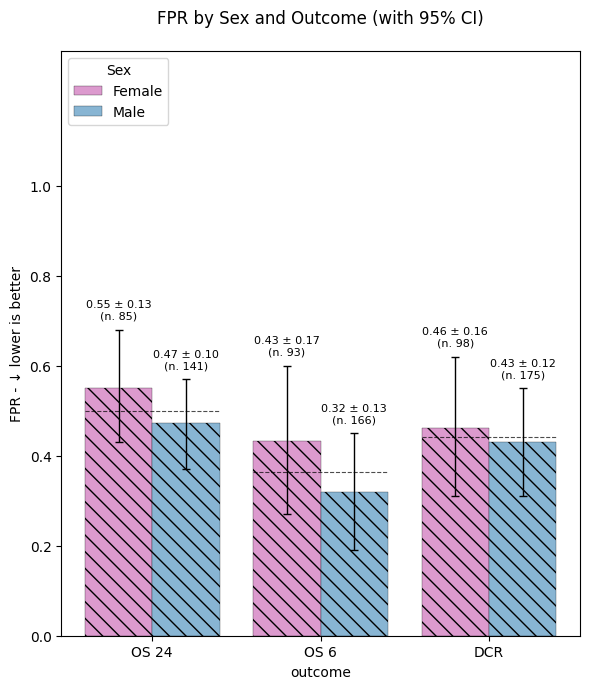

In [28]:
# Plot FPR by sex (test set)
plot_fairness_by_group(
    fairness_df=sex_fairness,
    metric='FPR',
    group_col='Sex',
    patients_per_outcome=sex_patients,
    outcome_thresholds=OUTCOME_THRESHOLDS_FPR
)

In [74]:
# Analyze race and sex fairness for each outcome (EXVAL)
OUTCOME_THRESHOLDS_TPR = {}
OUTCOME_THRESHOLDS_FPR = {}
exval_results = {}

for outcome_display_name, config in OUTCOME_CONFIG.items():
    results = analyze_exval_outcome_fairness_by_race(
        outcome=config['outcome'],
        outcome_name=config['outcome_name'],
        base_path='mlef_pipeline/results',
        n_perms=1000,
        random_state=42
    )
    exval_results[outcome_display_name] = results
    OUTCOME_THRESHOLDS_TPR[outcome_display_name] = results.get('threshold_tpr', None)
    OUTCOME_THRESHOLDS_FPR[outcome_display_name] = results.get('threshold_fpr', None)

# Create summary
race_fairness_summary, sex_fairness_summary = create_race_fairness_summary(exval_results)

print("Race-based fairness summary (EXVAL):")
display(race_fairness_summary)

print("\nSex-based fairness summary (EXVAL):")
display(sex_fairness_summary)


Analyzing EXVAL Race & Sex Fairness for OS 24

Loaded EXVAL predictions for OS_24:
  Samples: 190
  Columns in exval data: 2 (SEX, RACE)
  Subject order preserved: True

Overall EXVAL Performance (filtered by race):
  TPR (threshold): 0.960
  FPR (threshold): 0.878

Patients per race: {'WHITE': 91, 'BLACK OR AFRICAN AMERICAN': 90}
Patients per sex: {0: 119, 1: 71}


Race-based fairness analysis (EXVAL set)...
  TPR - WHITE: 0.946, BLACK OR AFRICAN AMERICAN: 0.973, p=1.0000
  FPR - WHITE: 0.870, BLACK OR AFRICAN AMERICAN: 0.887, p=1.0000

Sex-based fairness analysis (EXVAL set)...
  TPR - Female: 0.960, Male: 0.960, p=1.0000
  FPR - Female: 0.884, Male: 0.870, p=1.0000

Analyzing EXVAL Race & Sex Fairness for OS 6

Loaded EXVAL predictions for OS_6:
  Samples: 240
  Columns in exval data: 2 (SEX, RACE)
  Subject order preserved: True

Overall EXVAL Performance (filtered by race):
  TPR (threshold): 0.407
  FPR (threshold): 0.207

Patients per race: {'BLACK OR AFRICAN AMERICAN': 118, 'W

,Metric,Race,Value,CI,p-value,outcome
0,TPR,WHITE,0.945946,"(0.86, 1.0)",1.000000,OS 24
1,TPR,BLACK OR AFRICAN AMERICAN,0.972973,"(0.92, 1.0)",1.000000,OS 24
2,FPR,WHITE,0.870370,"(0.76, 0.94)",1.000000,OS 24
3,FPR,BLACK OR AFRICAN AMERICAN,0.886792,"(0.79, 0.96)",1.000000,OS 24
4,TPR,WHITE,0.435294,"(0.33, 0.54)",0.426573,OS 6
5,TPR,BLACK OR AFRICAN AMERICAN,0.377778,"(0.28, 0.47)",0.426573,OS 6
6,FPR,WHITE,0.240000,"(0.08, 0.4)",1.000000,OS 6
7,FPR,BLACK OR AFRICAN AMERICAN,0.214286,"(0.07, 0.36)",1.000000,OS 6
8,TPR,WHITE,0.434783,"(0.32, 0.55)",0.591409,DCR
9,TPR,BLACK OR AFRICAN AMERICAN,0.492308,"(0.37, 0.6)",0.591409,DCR



Sex-based fairness summary (EXVAL):


,Metric,Sex,Value,CI,p-value,outcome
0,TPR,Female,0.960000,"(0.9, 1.0)",1.000000,OS 24
1,TPR,Male,0.960000,"(0.88, 1.0)",1.000000,OS 24
2,FPR,Female,0.884058,"(0.81, 0.96)",1.000000,OS 24
3,FPR,Male,0.869565,"(0.78, 0.96)",1.000000,OS 24
4,TPR,Female,0.409091,"(0.31, 0.5)",1.000000,OS 6
5,TPR,Male,0.402778,"(0.29, 0.53)",1.000000,OS 6
6,FPR,Female,0.176471,"(0.06, 0.32)",0.540460,OS 6
7,FPR,Male,0.250000,"(0.08, 0.42)",0.540460,OS 6
8,TPR,Female,0.512195,"(0.4, 0.62)",0.224775,DCR
9,TPR,Male,0.400000,"(0.27, 0.53)",0.224775,DCR


Patients per race (EXVAL):
  OS 24: {'WHITE': 91, 'BLACK OR AFRICAN AMERICAN': 90}
  OS 6: {'BLACK OR AFRICAN AMERICAN': 118, 'WHITE': 110}
  DCR: {'BLACK OR AFRICAN AMERICAN': 125, 'WHITE': 113}

Patients per sex (EXVAL):
  OS 24: {'Female': 119, 'Male': 71}
  OS 6: {'Female': 144, 'Male': 96}
  DCR: {'Female': 148, 'Male': 103}


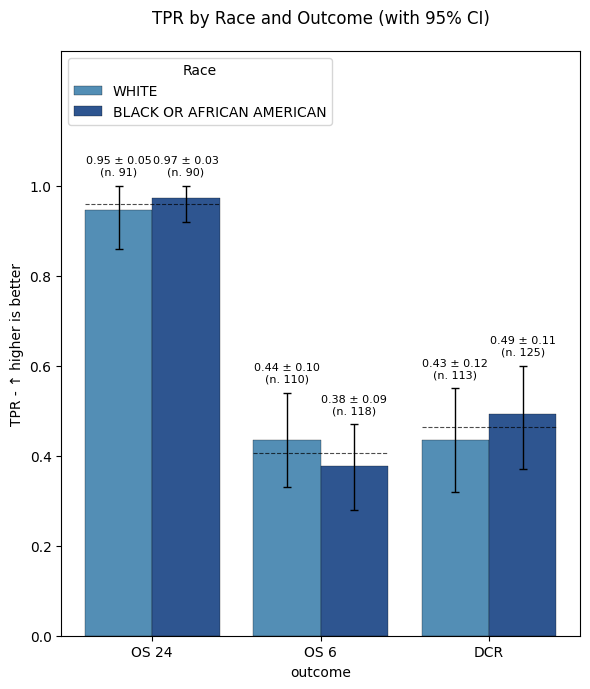

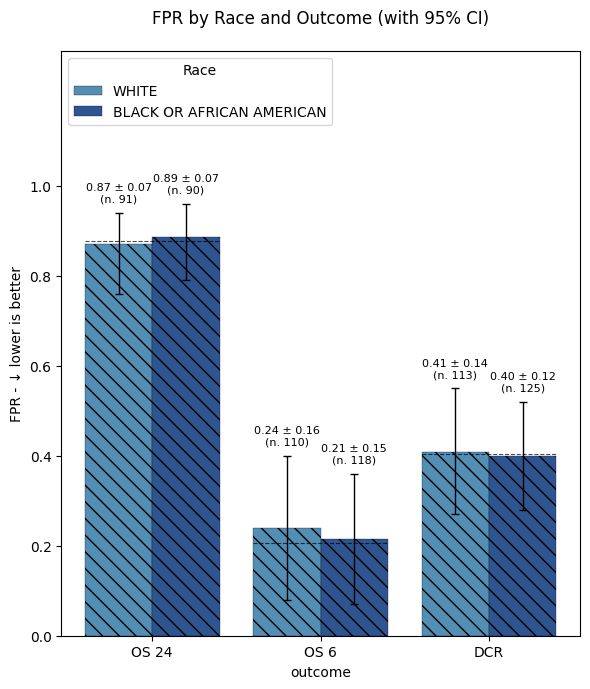

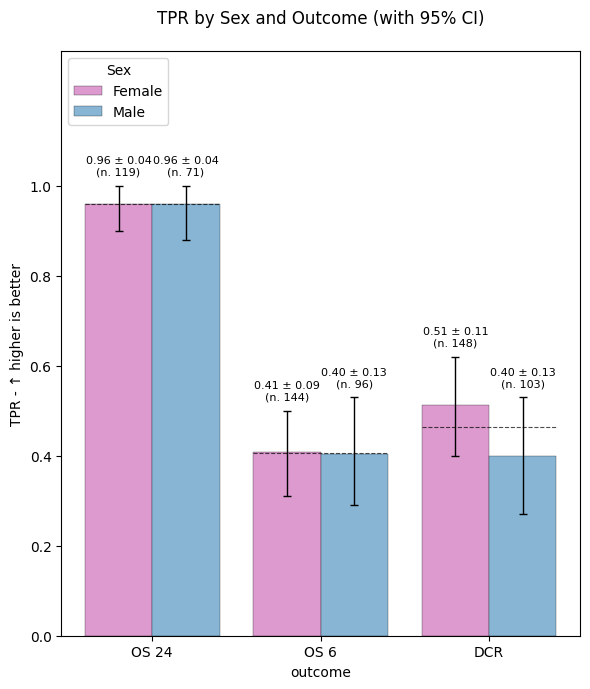

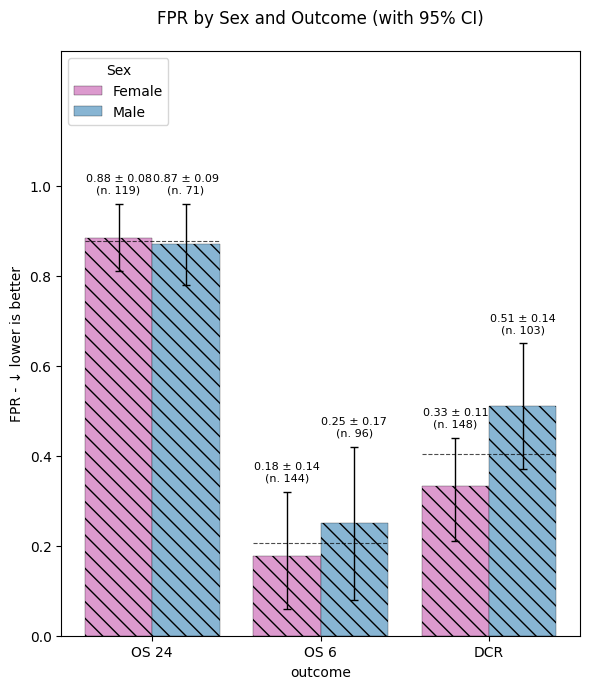

In [76]:
# Compute patient counts from results
exval_patients_race = {}
exval_patients_sex = {}

for outcome_name, results in exval_results.items():
    if results is None: continue
    exval_patients_race[outcome_name] = results['patients_per_race']
    exval_patients_sex[outcome_name] = results['patients_per_sex']

print("Patients per race (EXVAL):")
for outcome, counts in exval_patients_race.items():
    print(f"  {outcome}: {counts}")



sex_map = {0: "Female", 1: "Male"}

for outcome in exval_patients_sex:
    exval_patients_sex[outcome] = {
        sex_map[k]: v for k, v in exval_patients_sex[outcome].items()
    }
    
print("\nPatients per sex (EXVAL):")
for outcome, counts in exval_patients_sex.items():
    print(f"  {outcome}: {counts}")
# Plot TPR by race (EXVAL)
plot_fairness_by_group(
    fairness_df=race_fairness_summary,
    metric='TPR',
    group_col='Race',
    patients_per_outcome=exval_patients_race,
    outcome_thresholds=OUTCOME_THRESHOLDS_TPR
)

# Plot FPR by race (EXVAL)
plot_fairness_by_group(
    fairness_df=race_fairness_summary,
    metric='FPR',
    group_col='Race',
    patients_per_outcome=exval_patients_race,
    outcome_thresholds=OUTCOME_THRESHOLDS_FPR
)

# Plot TPR by sex (EXVAL)
plot_fairness_by_group(
    fairness_df=sex_fairness_summary,
    metric='TPR',
    group_col='Sex',
    patients_per_outcome=exval_patients_sex,
    outcome_thresholds=OUTCOME_THRESHOLDS_TPR
)

# Plot FPR by sex (EXVAL)
plot_fairness_by_group(
    fairness_df=sex_fairness_summary,
    metric='FPR',
    group_col='Sex',
    patients_per_outcome=exval_patients_sex,
    outcome_thresholds=OUTCOME_THRESHOLDS_FPR
)

# GLOBAL XAI
run this section to reproduce **figure 4** XAI graphs

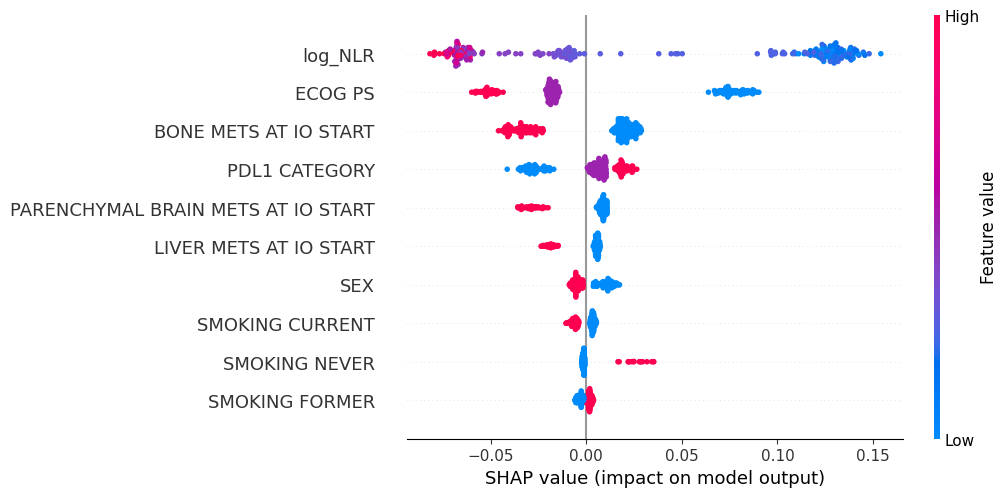

In [30]:
outcome = 'OS_24' #   'OS_6' | 'OS_24' | 'DCR'
model = joblib.load(f'mlef_pipeline/results/{outcome}/C23/RWD/model_RF.pkl')  # model_LR or model_RF
train = pd.read_csv(f'mlef_pipeline/results/{outcome}/C23/RWD/train_set.csv')
test = pd.read_csv(f'mlef_pipeline/results/{outcome}/C23/RWD/test_set.csv')
X_tr = train[model.feature_names_in_]
X_test = test[model.feature_names_in_]
shap_beeswarm(model, X_tr, X_test)